# PEGASE 9241 large-scale test

In [1]:
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import numpy as np
import networkx as nx

from powergrid_synth import (
    PowerGridGenerator,
    BusTypeAllocator,
    GraphComparator,
    CapacityAllocator,
    LoadAllocator,
    GenerationDispatcher,
    TransmissionLineAllocator,
    pandapower_to_nx,
    nx_to_pandapower,
    extract_topology_params_from_graph,
)

### Load the PEGASE 9241 grid using pandapower

In [2]:
# 1. Load Real Grid and Convert
print("\n[1] Loading Reference Grid (PEGASE 9241)...")
net_real = pn.case9241pegase()
graph_real = pandapower_to_nx(net_real)
base_kv_list = graph_real.graph['base_kv_map']
print(f"Loaded {graph_real.number_of_nodes()} nodes and {graph_real.number_of_edges()} edges.")


[1] Loading Reference Grid (PEGASE 9241)...
Loaded 9241 nodes and 14207 edges.


## Generate a synthetic grid

### Extract Topology Characteristics from Graph

In [3]:
print("\n[2] Analyzing Reference Topology...")
params = extract_topology_params_from_graph(graph_real)


[2] Analyzing Reference Topology...
Extracting topology parameters...


### PowerGridGenerator

In [4]:
# 3. Generate Synthetic Grid
print("\n[3] Generating Synthetic Clone...")
gen = PowerGridGenerator(seed=53)
synthetic_graph = gen.generate_grid(
    degrees_by_level=params['degrees_by_level'],
    diameters_by_level=params['diameters_by_level'],
    transformer_degrees=params['transformer_degrees'],
    keep_lcc=True
)


[3] Generating Synthetic Clone...
--- Starting Generation for 9 Voltage Levels ---
Generating Level 0...
  -> Level 0 Complete. Nodes: 5, Edges: 2
Generating Level 1...
  -> Level 1 Complete. Nodes: 144, Edges: 174
Generating Level 2...
  -> Level 2 Complete. Nodes: 2085, Edges: 2846
Generating Level 3...
  -> Level 3 Complete. Nodes: 4, Edges: 0
Generating Level 4...
  -> Level 4 Complete. Nodes: 3759, Edges: 4721
Generating Level 5...
  -> Level 5 Complete. Nodes: 838, Edges: 1013
Generating Level 6...
  -> Level 6 Complete. Nodes: 1854, Edges: 2031
Generating Level 7...
  -> Level 7 Complete. Nodes: 14, Edges: 3
Generating Level 8...
  -> Level 8 Complete. Nodes: 2077, Edges: 2555
Generating Transformer Connections...
  -> Connecting Level 0 <-> Level 2
  -> Connecting Level 0 <-> Level 3
  -> Connecting Level 1 <-> Level 2
  -> Connecting Level 1 <-> Level 5
  -> Connecting Level 2 <-> Level 3
  -> Connecting Level 2 <-> Level 4
  -> Connecting Level 2 <-> Level 6
  -> Connecting 

## Analysis

In [5]:
# 5. Compare using the Library Module
print("\n[5] Running Comparative Analysis...")
comparator = GraphComparator(
    synth_graph=synthetic_graph, 
    ref_graph=graph_real, 
    synth_label="Synthetic", 
    ref_label="PEGASE 9241"
)


[5] Running Comparative Analysis...


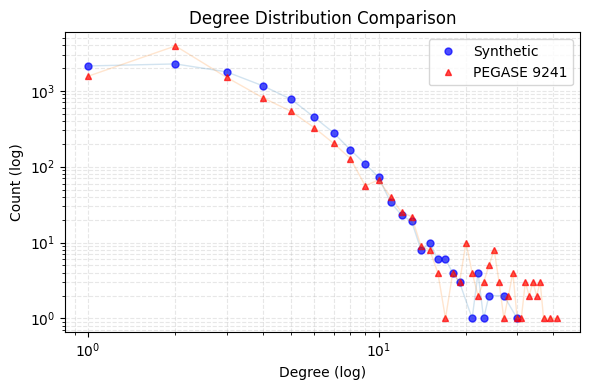

In [6]:
comparator.plot_degree_comparison(log_scale=True, fig_size=(6,4), show_lines=True,)

In [7]:
comparator.print_level_metrics()


LEVEL 0 COMPARISON
            Metric Synthetic PEGASE 9241
             Nodes         1           3
             Edges         0           2
           Density  0.000000    0.666667
        Connected?       Yes         Yes
    Diameter (LCC)         0           2
Avg Path Len (LCC)    0.0000      1.3333
    Avg Clustering    0.0000      0.0000
      Transitivity    0.0000      0.0000


LEVEL 1 COMPARISON
            Metric Synthetic PEGASE 9241
             Nodes       135         126
             Edges       174         174
           Density  0.019237    0.022095
        Connected?        No         Yes
    Diameter (LCC)        19          17
Avg Path Len (LCC)    7.4254      6.8424
    Avg Clustering    0.1246      0.0789
      Transitivity    0.1392      0.0845


LEVEL 2 COMPARISON
            Metric Synthetic PEGASE 9241
             Nodes      1911        1814
             Edges      2842        2706
           Density  0.001557    0.001646
        Connected?        No        

In [8]:
comparator.compare_degree_distributions()


DEGREE DISTRIBUTION COMPARISON  (KS & Relative Hausdorff)
  Level KS Statistic RH Distance
Level 0       1.0000      1.0000
Level 1       0.1873      0.1250
Level 2       0.0957      0.2353
Level 3       1.0000      1.0000
Level 4       0.0876      0.2000
Level 5       0.0995      0.2000
Level 6       0.1382      0.1333
Level 7       0.0286      0.0000
Level 8       0.2133      0.1667



Note that the large KS/RH values come from the ill-posed degree distributions on the corresponding voltage levels.

### Bus type assignment

In [9]:
# 4. Allocate Bus Types
print("\n[4] Allocating Bus Types via AIS...")
allocator = BusTypeAllocator(synthetic_graph, entropy_model=0, bus_type_ratio=[80,60,0])
bus_types = allocator.allocate(max_iter=50)
nx.set_node_attributes(synthetic_graph, bus_types, name="bus_type")


[4] Allocating Bus Types via AIS...
Starting Bus Type Allocation (N=9282, M=14947)...
  Target Entropy Score (W*): 1.5717, Std Dev: 0.0031
  Iter 0: Best Error = 0.132178
  Iter 10: Best Error = 0.127606
  Iter 20: Best Error = 0.125055
  Iter 30: Best Error = 0.122702
  Iter 40: Best Error = 0.120258


In [10]:
from collections import Counter

counts = Counter(bus_types.values())
total = sum(counts.values())
print(f"-----> Assignment Complete:")
print(f"       Generators: {counts['Gen']} ({counts['Gen']/total:.1%})")
print(f"       Loads:      {counts['Load']} ({counts['Load']/total:.1%})")
print(f"       Connectors: {counts['Conn']} ({counts['Conn']/total:.1%})")

-----> Assignment Complete:
       Generators: 5368 (57.8%)
       Loads:      3914 (42.2%)
       Connectors: 0 (0.0%)


### Generation capacities and load settings

In [11]:
print("\n[6] Allocating Capacity...")
cap_allocator = CapacityAllocator(synthetic_graph)
capacities = cap_allocator.allocate()
total_cap = sum(capacities.values())
print(f"Total Generation: {total_cap:.2f} MW")
nx.set_node_attributes(synthetic_graph, capacities, name="pg_max")


[6] Allocating Capacity...
Allocating Capacity for 5368 generators.
Total System Capacity Target: 336886.73 MW using Reference System 1
Total Generation: 336886.73 MW


In [12]:
# Check top 10 generators
sorted_gens = sorted(capacities.items(), key=lambda x: x[1], reverse=True)
print("\nTop 5 Generators by Capacity:")
for node, cap in sorted_gens[:5]:
    print(f"  Node {node}: {cap:.2f} MW (Degree: {synthetic_graph.degree(node)})")


Top 5 Generators by Capacity:
  Node 6692: 1701.77 MW (Degree: 4)
  Node 7595: 1682.40 MW (Degree: 4)
  Node 7059: 1630.22 MW (Degree: 4)
  Node 8270: 1628.88 MW (Degree: 4)
  Node 8099: 1622.55 MW (Degree: 4)


In [13]:
print("\n[7] Allocating Loads ...")
load_allocator = LoadAllocator(synthetic_graph, ref_sys_id=1)
loads = load_allocator.allocate(loading_level='H')

nx.set_node_attributes(synthetic_graph, loads, name="pl")

total_load = sum(loads.values())
print(f"Total Load: {total_load:.2f} MW")
print(f"System Loading: {total_load/total_cap:.1%}")


[7] Allocating Loads ...
Allocating Loads for 3914 load buses.
Total System Load Target: 241698.38 MW (Level: H)
Total Load: 241698.38 MW
System Loading: 71.7%


In [14]:
print("\n[8] Dispatching Generation...")
dispatcher = GenerationDispatcher(synthetic_graph, ref_sys_id=1)
dispatch = dispatcher.dispatch()
nx.set_node_attributes(synthetic_graph, dispatch, name="pg")
total_gen = sum(dispatch.values())
print(f"-> Total Power Dispatched: {total_gen:.2f} MW")
print(f"-> Generation Reserve: { total_cap - total_gen:.2f} MW")


[8] Dispatching Generation...
-> Total Power Dispatched: 138527.01 MW
-> Generation Reserve: 198359.73 MW


In [15]:
print("\n[9] Allocating Transmission Lines (Impedance & Capacity)...")
trans_allocator = TransmissionLineAllocator(synthetic_graph, ref_sys_id=1)
line_caps = trans_allocator.allocate()

total_lines = len(line_caps)
avg_cap = sum(line_caps.values()) / total_lines if total_lines > 0 else 0
print(f"-> Allocated {total_lines} Lines")
print(f"-> Average Line Capacity: {avg_cap:.2f} MVA")


[9] Allocating Transmission Lines (Impedance & Capacity)...
-> Allocated 14947 Lines
-> Average Line Capacity: 347.97 MVA


### Convert to pandapower network

In [16]:
synthetic_net = nx_to_pandapower(synthetic_graph, base_kv_map=base_kv_list)
synthetic_net

This pandapower network includes the following parameter tables:
   - bus (9282 elements)
   - load (3914 elements)
   - gen (5367 elements)
   - ext_grid (1 element)
   - line (13234 elements)
   - trafo (1713 elements)

In [17]:
pp.rundcpp(synthetic_net)
synthetic_net

This pandapower network includes the following parameter tables:
   - bus (9282 elements)
   - load (3914 elements)
   - gen (5367 elements)
   - ext_grid (1 element)
   - line (13234 elements)
   - trafo (1713 elements)
 and the following results tables:
   - res_bus (9282 elements)
   - res_line (13234 elements)
   - res_trafo (1713 elements)
   - res_ext_grid (1 element)
   - res_load (3914 elements)
   - res_gen (5367 elements)

## Compatible with pandapower

[pandapower](https://www.pandapower.org/) provides **Newton-Raphson AC** (`pp.runpp`) and **linear DC** (`pp.rundcpp`) power-flow solvers, and export to **JSON, Excel, SQLite, Pickle**.

> **Note:** `pp.runpp` (AC) may not converge for large synthetic grids; `pp.rundcpp` (DC) always works. For AC power flow on large grids, use pypowsybl's `run_ac` solver instead (shown below).

## Compatible with PowSyBl

[pypowsybl](https://pypowsybl.readthedocs.io/) provides **AC and DC load-flow solvers** (`run_ac`, `run_dc`), interactive grid visualisation, and export to **CGMES, XIIDM, MATPOWER, PSS/E, UCTE, AMPL, BIIDM, JIIDM**.

### Supported data export formats

PowerGridSynth provides a unified `GridExporter` class that wraps the built-in export functions of **pandapower** and **pypowsybl**, supporting **12+ industry-standard data formats** out of the box.

| Via | Formats | Methods |
|-----|---------|--------|
| **pandapower** | JSON, Excel, SQLite, Pickle | `to_json()`, `to_excel()`, `to_sqlite()`, `to_pickle()` |
| **pypowsybl** | CGMES, XIIDM, MATPOWER, PSS/E, UCTE, AMPL, BIIDM, JIIDM | `to_cgmes()`, `to_matpower()`, `to_psse()`, `to_pypowsybl(format=...)` |

In [18]:
from powergrid_synth import GridExporter

exporter = GridExporter(synthetic_graph, base_kv_map=base_kv_list)

# --- pandapower-based exports ---
exporter.to_json("output/pegase9241_syn.json")

# --- pypowsybl-based exports ---
exporter.to_cgmes("output/pegase9241_syn_cgmes")
exporter.to_matpower("output/pegase9241_syn")
exporter.to_psse("output/pegase9241_syn")
exporter.to_pypowsybl("output/pegase9241_syn.xiidm", format="XIIDM")

-> pandapower JSON export: output/pegase9241_syn.json
-> pypowsybl CGMES export: output/pegase9241_syn_cgmes
-> pypowsybl MATPOWER export: output/pegase9241_syn
-> pypowsybl PSS/E export: output/pegase9241_syn
-> pypowsybl XIIDM export: output/pegase9241_syn.xiidm


In [19]:
import pypowsybl as ppl

#### Convert from pandapower dataframe to pypowsybl network

In [20]:
from powergrid_synth import pandapower_to_pypowsybl

In [21]:
ppl_net = pandapower_to_pypowsybl(synthetic_net)

In [22]:
ppl_net

Network(id=network, name=network, case_date=2026-04-14 11:44:49.021000+00:00, forecast_distance=0:00:00, source_format=)

#### Run AC PF solver using PowSyBl

In [23]:
ppl.loadflow.run_ac(ppl_net)

[ComponentResult(connected_component_num=0, synchronous_component_num=0, status=MAX_ITERATION_REACHED, status_text=Reached Newton-Raphson max iterations limit, iteration_count=16, reference_bus_id='sub_6692_0', slack_bus_results=[SlackBusResult(id='sub_6692_0', active_power_mismatch=19861584.66239525)], distributed_active_power=0.0)]